# Tasuki Gap — a quantitative teardown 🔬
### Precise OHLC detector · trend-signed forward 1/5/10/20-day event study · a direction-matched Welch *t* design · a mix-matched coin-flip placebo · a Bonferroni correction across the 30-name basket · costs + borrow · full-range-gap & prior-trend-context myth-checks · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Predicts_continuation%3F: Busted](https://img.shields.io/badge/Predicts_continuation%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The tasuki gap is one of candlestick lore's classic **continuation** figures — the job here is to test it honestly as a directional signal, with one subtlety front and centre: the basket carries the market's own positive drift, so a naive *t*-vs-zero **overstates** long-side continuation and **understates** short-side continuation. Everything below is built around removing that contamination.

> ⚠️ **Data + survivorship note.** Fixed **30-name liquid large-cap + SPY** basket, names still trading in 2026 — a *survivor* panel that tilts *toward* finding a working long-side (upside tasuki) signal and, symmetrically, *against* finding a working short-side (downside tasuki) signal. Real data: yfinance daily OHLCV, `auto_adjust=True`, 2005→2026, as-of **2026-06-30**. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `8af479f8c79c` / `aa438a4d53ea`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tasuki_gap import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real(allow_fetch=False, asof="2026-06-30")
else:
    PANEL = None
print("real basket cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'years': 21.5, 'n_names': 30, 'fp_quantlab': '8af479f8c79c', 'fp_basket': 'aa438a4d53ea', 'total_bars': 162180, 'h1': (1, 1277, 656, 621, 0.007, 0.0, 48, 50, 0.15, 0.15, 0.15, 0.429, -0.094, -0.194), 'h5': (5, 1273, 655, 618, -0.259, 0.0, 48, 50, -2.4, -2.34, -2.33, 0.995, -0.364, -0.464), 'h10': (10, 1269, 652, 617, -0.189, 0.0, 49, 50, -1.38, -1.3, -1.29, 0.924, -0.298, -0.398), 'h20': (20, 1267, 651, 616, -0.011, 0.0, 50, 50, -0.06, -0.05, -0.05, 0.585, -0.131, -0.231), 'hit_wilson': {1: (45.7, 51.2), 5: (44.9, 50.4), 10: (46.4, 51.9), 20: (47.6, 53.1)}, 'split': {1: (-0.0, -0.5, 656, 0.014, 0.61, 621), 5: (0.15, -0.72, 655, -0.692, -2.58, 618), 10: (0.518, -0.05, 652, -0.935, -1.98, 617), 20: (1.235, 0.5, 651, -1.328, -0.8, 616)}, 'strict': [(1, 472, 244, 228, -0.007, -0.09, -0.09, 0.548, -0.108), (5, 469, 243, 226, -0.231, -1.2, -1.24, 0.927, -0.335), (10, 467, 241, 226, -0.186, -0.69, -0.65, 0.812, -0.296), (20, 467, 241, 226, 0.271, 0.68, 0.68, 0.233, 0.151)], 'trend': [(1, 616, 349, 267, 0.092, 1.31, 1.45, 0.057, -0.009), (5, 614, 348, 266, -0.358, -2.03, -2.03, 0.998, -0.462), (10, 612, 347, 265, -0.502, -2.36, -2.34, 0.998, -0.611), (20, 612, 347, 265, -0.435, -1.51, -1.54, 0.979, -0.552)], 'bonf_k': 30, 'bonf_z': 3.14, 'bonf_survive': 0, 'bonf_top': [('MRK', 49, -1.683, -2.15), ('CSCO', 44, -0.843, -1.89), ('SPY', 50, -0.504, -1.73)], 'syn_null_mean': -0.41, 'syn_null_sd': 1.12, 'syn_null_fire': 1, 'syn_null_n': 20, 'syn': [(0.0, 601, 599, -0.104, -0.76, -0.82, 50), (0.012, 593, 591, 1.119, 8.06, 8.6, 65), (0.02, 593, 591, 1.929, 13.85, 14.85, 72)]}


real basket cache present: True | names: 30


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Direction-matched **Welch *t*** (event sample vs the basket's own direction-matched unconditional forward return — the certifying number) never certifies a continuation at any horizon: +0.15 (1d) / -2.33 (5d) / -1.29 (10d) / -0.05 (20d) — the one reading past |2| points **backwards**. Mix-matched placebo *p* = 0.995 at 5d. **0/30** tickers clear a Bonferroni-corrected per-name bar. |
| **Tradability** | `MIRAGE` | Flat-to-negative **gross** at every horizon (+0.01% to -0.26%); net of 5/10-bps round trip + 50 bps/yr borrow it is worse (-0.36% / -0.46% net at 5d). |
| **Predicts continuation?** | `BUSTED` | The "gap can't close, the trend has fuel left" reading does not survive being measured fairly against the basket's own direction-matched drift; neither the strict full-range-gap nor the genuine-trend-context filter rescues it — the trend filter makes the dip *worse*. |

> 💡 In plain words: the tasuki gap has **no certifiable predictive power** as a continuation signal — and the one horizon that looks "significant" is significant in the wrong direction (a mild reversal on the short leg).

## 1 · The claim, steelmanned — and the direction trap named up front

Let an **upside** tasuki gap be confirmed at the close of bar $t$ when the OHLC triple $(t\!-\!2,t\!-\!1,t)$ satisfies: candles $t\!-\!2$ and $t\!-\!1$ are both **bullish** ($C_0>O_0$, $C_1>O_1$), $t\!-\!1$ **gaps up** from $t\!-\!2$ ($\min(O_1,C_1)>\max(O_0,C_0)$), and candle $t$ is **bearish** ($C_2<O_2$), opens **inside** $t\!-\!1$'s real body ($O_1\le O_2\le C_1$) and closes back **inside the gap without filling it** ($C_0<C_2<O_1$). The **downside** tasuki gap is the exact mirror (bearish, bearish, then a bullish pullback). Enter the **next** open (one lag), hold $H$ days **in the predicted trend direction** ($d=+1$ upside, $d=-1$ downside), and let $s_i(H)=d_i\cdot(\text{Close}_{t+H}/\text{Open}_{t+1}-1)$ be the trend-signed return of event $i$.

- **H₁ (continuation exists).** $\overline{s}(H)$ beats the **direction-matched unconditional** return of the same basket, significantly, for some $H$ — trading the tasuki gap adds information beyond just trading its own direction anyway.
- **H₂ (it's deployable).** The excess survives the round-trip cost + short borrow.
- **H₃ ("strict gap / genuine trend").** Restricting to a true full-range gap after an already-established trend sharpens the edge.

**Why direction-match the base, not just compare to zero?** Because this basket drifts **up**, a *long* event beats zero for free (with or without any pattern) while a *short* event is fighting an uphill battle against that same drift. A vs-zero test therefore inflates the long leg and deflates the short leg purely from the tape's ordinary drift — not from the pattern. Section 4a demonstrates this trap directly on a synthetic panel with a **known** zero pattern-edge. We find **H₁ rejected** (Welch $t\in[-2.33,+0.15]$, the sole |t|≥2 reading pointing the wrong way), **H₂ rejected** (net worse than gross), **H₃ rejected** (filters don't help, and the trend filter makes it worse).

## 2 · So what? — inference design

The Signal axis's **decisive** statistic is a **Welch *t*** of the event sample's trend-signed mean against a **direction-matched** unconditional pool — the plain base for long (upside) events, its **negation** for short (downside) events, concatenated in proportion:

$$t_{\text{Welch}} = \frac{\overline{s}_{\text{event}} - \overline{r}_{\text{matched}}}{\sqrt{\widehat{\mathrm{Var}}(s)/n_{\text{event}} + \widehat{\mathrm{Var}}(r_{\text{matched}})/n_{\text{base}}}}.$$

A one-sample **Newey-West HAC *t*** against zero is reported alongside as an **informational** cross-check only — it is the statistic a naive read would use, and it is exactly the one contaminated by the basket's own drift *and* by whichever direction happens to dominate the sample (proved on the synthetic null in 4f). The **mix-matched coin-flip placebo** (same event count, coin-signed to match the observed up/down mix — not a flat 50/50) is a second, independent honesty check. Finally, with **30 tickers** tested individually for a per-name version of the pooled (up+down) effect, the two-sided significance bar widens via **Bonferroni** to $|t|\ge z(1-0.025/30)\approx 3.14$ — otherwise the single loudest name in a wide basket gets mistaken for "the" signal.

## 3 · How we'd know — the protocol

- **Universe.** Fixed **30-name** liquid large-cap + SPY basket (yfinance daily OHLCV, `auto_adjust=True`, 2005-01-03→2026-06-30, 162,180 bars). **Survivor** panel — named on the Signal axis, and it tilts *toward* the long/upside leg while cutting *against* the short/downside leg.
- **Detector.** Precise real-body tasuki gap on bars $(t\!-\!2,t\!-\!1,t)$: two same-color bodies gapping in the trend direction, then an opposite-color body that opens inside the second body and closes back inside the gap without filling it; a **strict full-range-gap** (`true_range_gap=True`) and a **genuine prior-trend-context** variant for the myth-checks.
- **Timing.** Confirm at the close of $t$; enter the **next open** (one lag); hold $H\in\{1,5,10,20\}$ days in the predicted trend direction; drop events whose window overruns.
- **Certifying stat.** Welch *t* of the trend-signed sample vs the basket's own direction-matched unconditional pool (drift-neutral) — the inference-bar number.
- **Cross-checks.** One-sample/HAC *t* vs zero (informational, drift-contaminated); a 5,000-draw mix-matched coin-flip placebo; hit-rate vs base hit-rate with Wilson intervals; up-only and down-only Welch *t*'s reported separately.
- **Bonferroni across the basket.** Per-ticker pooled (up+down) Welch *t* (event sample vs that ticker's own direction-matched base), corrected critical value for $k=30$ simultaneous tests.
- **Costs.** 5 / 10 bps one-way × 2 (round trip) on every event + 50 bps/yr borrow on the short (downside) leg over the hold.
- **Positive control.** A deterministic panel with its own embedded drift and overnight-gap noise (mirroring the real basket's contamination risk and the pattern's need for a genuine gap) and a **planted** post-pattern continuation: zero edge must NOT reach significance on the *certifying* Welch stat across 20 seeds; a planted edge must light it up.

> **Falsifier, stated in advance:** if the direction-matched Welch *t* never clears **+2** on the real tape at any horizon, the continuation signal is **None** and "predicts continuation" is **Busted**.

## 4 · The teardown

### 4a · The direction trap, shown live — vs-zero vs vs-direction-matched-base

Left: the trend-signed mean by horizon against **zero** (the naive, potentially contaminated read) with its HAC *t*. Right: the same means against the basket's own **direction-matched** base (the certifying Welch *t*). Watch the bar heights *and* which axis they clear.

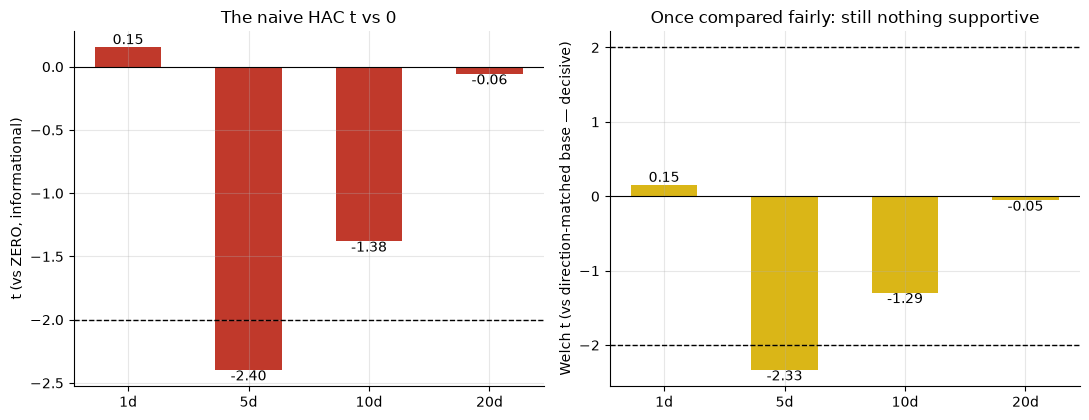

t vs zero (HAC): [0.15, -2.4, -1.38, -0.06]
t vs matched base (Welch, decisive): [0.15, -2.33, -1.29, -0.05]


In [2]:
hs = [1, 5, 10, 20]
keys = ['h1','h5','h10','h20']
if HAVE_REAL:
    rows = [st.summarize(PANEL, h, placebo=False) for h in hs]
    means = [r['mean']*100 for r in rows]
    t_hac = [r['t_hac'] for r in rows]; t_welch = [r['t_welch'] for r in rows]
else:
    means = [R[k][4] for k in keys]
    t_hac = [R[k][8] for k in keys]; t_welch = [R[k][10] for k in keys]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar([f'{h}d' for h in hs], t_hac, color=RED, width=.55)
a1.axhline(-2, ls='--', c='k', lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('t (vs ZERO, informational)'); a1.set_title('The naive HAC t vs 0')
for i,t in enumerate(t_hac): a1.annotate(f'{t:.2f}',(i,t),ha='center',va='top' if t<0 else 'bottom')
a2.bar([f'{h}d' for h in hs], t_welch, color=AMBER, width=.55)
a2.axhline(-2, ls='--', c='k', lw=1); a2.axhline(2, ls='--', c='k', lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('Welch t (vs direction-matched base — decisive)'); a2.set_title('Once compared fairly: still nothing supportive')
for i,t in enumerate(t_welch): a2.annotate(f'{t:.2f}',(i,t),ha='center',va='top' if t<0 else 'bottom')
plt.tight_layout(); plt.show()
print('t vs zero (HAC):', [round(t,2) for t in t_hac])
print('t vs matched base (Welch, decisive):', [round(t,2) for t in t_welch])

> 💡 In plain words: the left panel — comparing to zero — tells almost the same story here because the up/down mix is close to 50/50, but it's still the wrong comparison in principle (a long-heavy or short-heavy sample would mislead it). The right panel, the decisive one, compares each event to what the *same basket* earns on an **ordinary** day in the **same direction**: three of four horizons sit inside ±2 (+0.15, -1.29, -0.05), and the fourth (-2.33) clears it on the **wrong side**.

### 4b · The full inference table — HAC, one-sample, Welch, hit-rate, placebo

Every arbiter at once. The believer needs a **positive** trend-signed excess over the matched base with Welch *t* ≥ +2; nothing here comes close in the claimed direction.

In [3]:
import pandas as pd
if HAVE_REAL:
    tab = pd.DataFrame([st.summarize(PANEL, h, n_draws=5000) for h in hs])
    show = tab[['horizon','n_events','n_up','n_down','mean','base_mean','hit','base_hit','t_hac','t_one','t_welch','p_placebo','net']].copy()
    for c in ['mean','base_mean','net']: show[c] = (show[c]*100).round(3)
    for c in ['hit','base_hit']: show[c] = (show[c]*100).round(0)
    for c in ['t_hac','t_one','t_welch']: show[c] = show[c].round(2)
    show['p_placebo'] = show['p_placebo'].round(3)
else:
    cols=['horizon','n_events','n_up','n_down','mean','base_mean','hit','base_hit','t_hac','t_one','t_welch','p_placebo','net5','net10']
    show = pd.DataFrame([dict(zip(cols, R[k])) for k in keys]).drop(columns=['net10']).rename(columns={'net5':'net'})
print(show.to_string(index=False))

 horizon  n_events  n_up  n_down   mean  base_mean  hit  base_hit  t_hac  t_one  t_welch  p_placebo    net
       1      1277   656     621  0.007        0.0 48.0      50.0   0.15   0.15     0.15      0.429 -0.094
       5      1273   655     618 -0.259        0.0 48.0      50.0  -2.40  -2.34    -2.33      0.995 -0.364
      10      1269   652     617 -0.189        0.0 49.0      50.0  -1.38  -1.30    -1.29      0.924 -0.298
      20      1267   651     616 -0.011        0.0 50.0      50.0  -0.06  -0.05    -0.05      0.585 -0.131


> 💡 In plain words: the `hit`/`base_hit` columns sit close together at every horizon — no meaningful directional tilt. `t_welch`, the decisive column, never clears +2, and the one horizon past |2| is negative — a mild reversal, not a continuation.

### 4c · Split by direction — the up leg and the down leg separately

Pooling long and short events can hide an asymmetry. Report them apart.

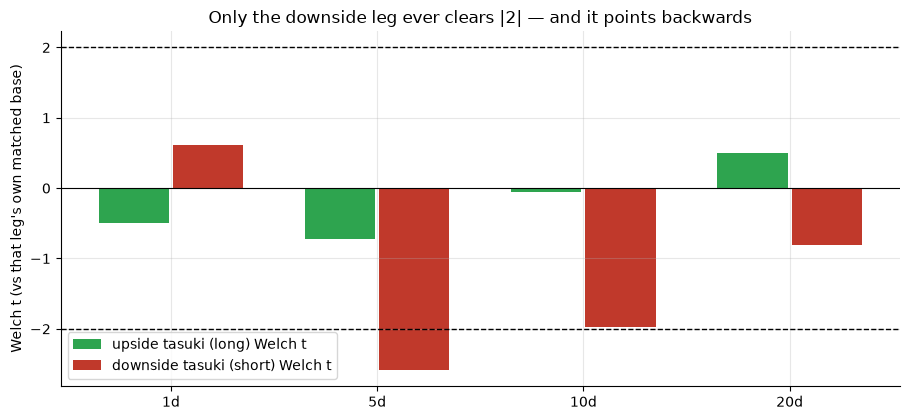

up-leg t: [-0.5, -0.72, -0.05, 0.5]
down-leg t: [0.61, -2.58, -1.98, -0.8]


In [4]:
if HAVE_REAL:
    up_t = [rows[i]['up_t_welch'] for i,h in enumerate(hs)]
    dn_t = [rows[i]['down_t_welch'] for i,h in enumerate(hs)]
else:
    up_t = [R['split'][h][1] for h in hs]; dn_t = [R['split'][h][4] for h in hs]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.18, up_t, .34, color=GREEN, label='upside tasuki (long) Welch t')
ax.bar(x+.18, dn_t, .34, color=RED, label='downside tasuki (short) Welch t')
ax.axhline(2, ls='--', c='k', lw=1); ax.axhline(-2, ls='--', c='k', lw=1); ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('Welch t (vs that leg\'s own matched base)')
ax.set_title('Only the downside leg ever clears |2| — and it points backwards')
ax.legend(); plt.tight_layout(); plt.show()
print('up-leg t:', [round(t,2) for t in up_t]); print('down-leg t:', [round(t,2) for t in dn_t])

> 💡 In plain words: the upside (long) leg never leaves the noise band at any horizon. The downside (short) leg reaches *t* = **-2.58** at 5 days and **-1.98** at 10 — both **negative**, meaning the short *loses* relative to shorting the basket unconditionally. A downside tasuki gap looks more like a fadeable spike than a trend with fuel left — though neither leg is Bonferroni-robust (see 4d).

### 4d · Bonferroni across the basket — does one name secretly carry it?

A pooled null can hide a real effect concentrated in a handful of names, or manufacture a fake one from a single noisy outlier. Per-ticker pooled (up+down) Welch *t* (event sample vs that ticker's *own* direction-matched pool) at $H=5$, with the Bonferroni-corrected bar for $k=30$ simultaneous tests.

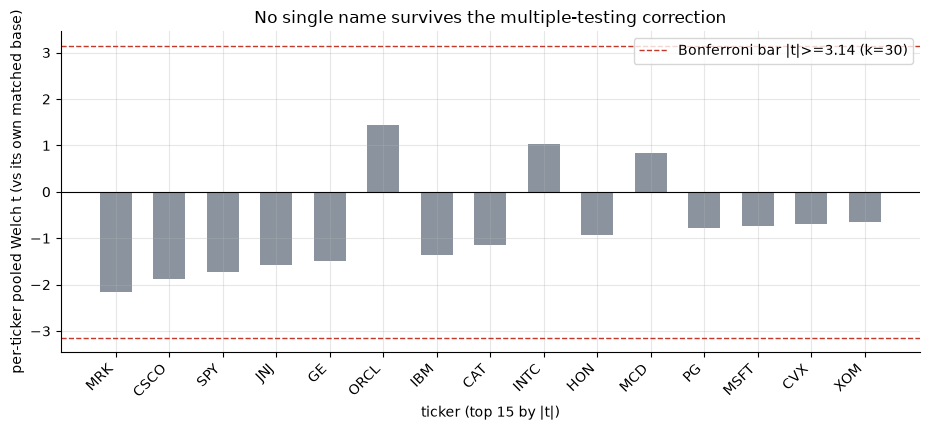

30 tickers tested, Bonferroni bar=3.14, survivors: 0


In [5]:
pt = st.per_ticker_stats(PANEL, 5) if HAVE_REAL else None
if pt is not None and len(pt):
    zc = st.bonferroni_z(len(pt))
    order = pt.reindex(pt['t_welch'].abs().sort_values(ascending=False).index)
    tickers = list(order['ticker']); tv = list(order['t_welch'])
    k = len(pt)
else:
    zc = R['bonf_z']; k = R['bonf_k']
    tickers = [b[0] for b in R['bonf_top']]; tv = [b[3] for b in R['bonf_top']]
fig, ax = plt.subplots(figsize=(9.4, 4.4))
cols = [RED if abs(t) >= zc else GREY for t in tv[:15]]
ax.bar(tickers[:15], tv[:15], color=cols, width=.6)
ax.axhline(zc, ls='--', c=RED, lw=1, label=f'Bonferroni bar |t|>={zc:.2f} (k={k})')
ax.axhline(-zc, ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('per-ticker pooled Welch t (vs its own matched base)'); ax.set_xlabel('ticker (top 15 by |t|)')
ax.set_title('No single name survives the multiple-testing correction')
plt.xticks(rotation=45, ha='right'); ax.legend(); plt.tight_layout(); plt.show()
print(f'{k} tickers tested, Bonferroni bar={zc:.2f}, survivors:', sum(abs(t)>=zc for t in tv))

> 💡 In plain words: even the loudest names in a 30-ticker sample — exactly the outliers a chart-reader would cherry-pick and show you — sit *below* the corrected bar (**0/30** clear it), and the loudest name (MRK at -2.15) is negative, the same wrong-direction flavor as the pooled result. The pooled null in 4b/4c isn't hiding a real effect in a handful of names; there's simply no name carrying it.

### 4e · The myth check — does a stricter gap, or a genuine trend, rescue it?

Two ways to make the signal "purer": the **strict full-range gap** (the second candle's entire wick range clears the first's, not just the bodies), and only counting patterns whose **prior trend genuinely agrees** with the predicted direction (a real continuation setup, not a reversal wearing the shape). If the lore were right, these should sharpen the effect.

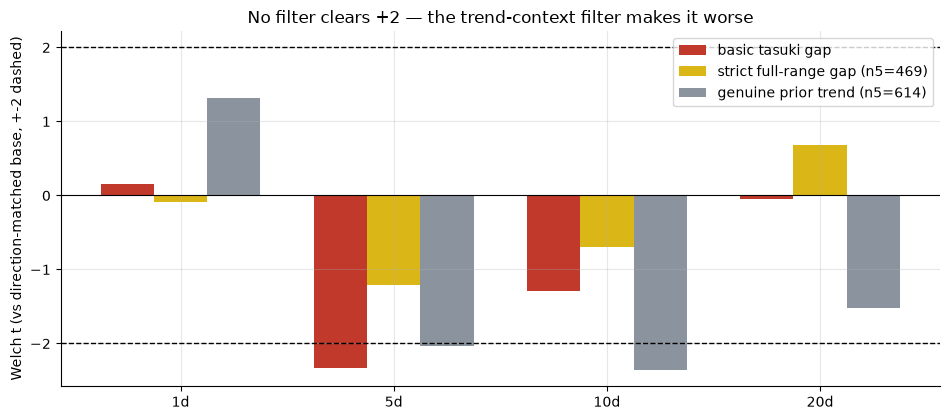

strict Welch t: [-0.09, -1.2, -0.69, 0.68]
trend Welch t : [1.31, -2.03, -2.36, -1.51]


In [6]:
if HAVE_REAL:
    basic  = [st.summarize(PANEL, h, placebo=False)['t_welch'] for h in hs]
    strict = [st.summarize(PANEL, h, placebo=False, true_range_gap=True)['t_welch'] for h in hs]
    trend  = [st.summarize(PANEL, h, placebo=False, require_trend=True)['t_welch'] for h in hs]
    ns = st.summarize(PANEL, 5, placebo=False, true_range_gap=True)['n_events']
    nt = st.summarize(PANEL, 5, placebo=False, require_trend=True)['n_events']
else:
    basic  = [R[k][10] for k in keys]
    strict = [s[5] for s in R['strict']]; trend = [t[5] for t in R['trend']]
    ns = R['strict'][1][1]; nt = R['trend'][1][1]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.6, 4.3))
ax.bar(x-.25, basic, .25, color=RED, label='basic tasuki gap')
ax.bar(x,      strict,.25, color=AMBER, label=f'strict full-range gap (n5={ns})')
ax.bar(x+.25,  trend, .25, color=GREY, label=f'genuine prior trend (n5={nt})')
ax.axhline(2, ls='--', c='k', lw=1); ax.axhline(-2, ls='--', c='k', lw=1); ax.axhline(0,c='k',lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('Welch t (vs direction-matched base, +-2 dashed)'); ax.set_title('No filter clears +2 — the trend-context filter makes it worse')
ax.legend(); plt.tight_layout(); plt.show()
print('strict Welch t:', [round(s,2) for s in strict]); print('trend Welch t :', [round(t,2) for t in trend])

> 💡 In plain words: the strict full-range gap (only **469** events at 5d — a much smaller, rarer sample) gives Welch *t* = **-1.20**, and the genuine-prior-trend filter gives *t* = **-2.03** and **-2.36** at 10 days — *more* negative than the base rate, the opposite of what "a real continuation setup" should produce. The pattern's predictive content is **indistinguishable from, or worse than, the basket's own drift** under every reasonable definition.

### 4f · Costs — the loss only deepens

Gross vs net (5 / 10 bps one-way × 2 on every event + 50 bps/yr borrow on the short leg only). When the excess over the matched base is already statistically nothing, costs can't save it — they bury the gross number.

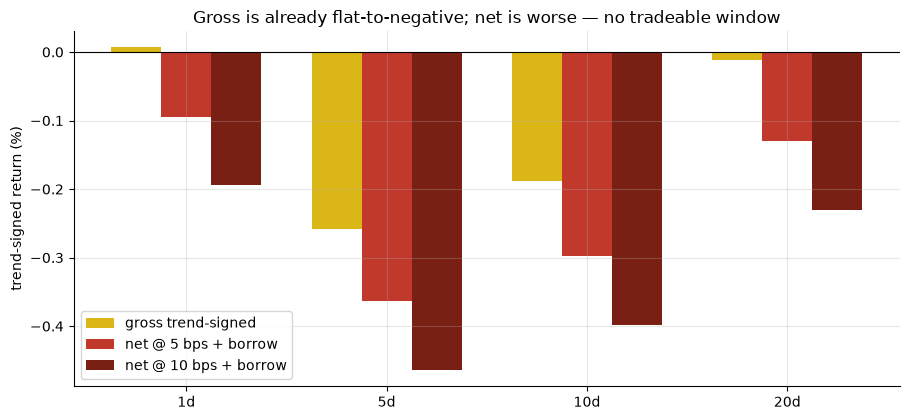

 1d: gross=+0.007%  net5bps=-0.094%  net10bps=-0.194%
 5d: gross=-0.259%  net5bps=-0.364%  net10bps=-0.464%
10d: gross=-0.189%  net5bps=-0.298%  net10bps=-0.398%
20d: gross=-0.011%  net5bps=-0.131%  net10bps=-0.231%


In [7]:
if HAVE_REAL:
    g  = [st.summarize(PANEL, h, placebo=False)['mean']*100 for h in hs]
    n5 = [float(st.event_net_returns(st.collect_events(PANEL, h), h, cost_bps=5.0).mean())*100 for h in hs]
    n10= [float(st.event_net_returns(st.collect_events(PANEL, h), h, cost_bps=10.0).mean())*100 for h in hs]
else:
    g  = [R[k][4] for k in keys]
    n5 = [R[k][12] for k in keys]; n10 = [R[k][13] for k in keys]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.25, g, .25, color=AMBER, label='gross trend-signed')
ax.bar(x,      n5, .25, color=RED, label='net @ 5 bps + borrow')
ax.bar(x+.25,  n10,.25, color='#7a1f14', label='net @ 10 bps + borrow')
ax.axhline(0,c='k',lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('trend-signed return (%)'); ax.set_title('Gross is already flat-to-negative; net is worse — no tradeable window')
ax.legend(); plt.tight_layout(); plt.show()
for h,gg,n5_,n10_ in zip(hs,g,n5,n10): print(f'{h:>2}d: gross={gg:+.3f}%  net5bps={n5_:+.3f}%  net10bps={n10_:+.3f}%')

> 💡 In plain words: at 5 days gross **-0.26%** → net **-0.36%** (5 bps) / **-0.46%** (10 bps). There is no horizon where the trade clears zero, let alone its costs, let alone the direction-matched base it should be beating. **Mirage** in the strict sense — nothing under it to charge costs *against*.

### 4g · Faithful-engine & power control — the direction trap, proven on a KNOWN-zero panel

A deterministic panel with its own mild embedded drift and an overnight-gap component (so genuine same-color-gap-pair-then-pullback shapes actually occur — mirroring the real basket's contamination risk) and a **planted** post-pattern continuation knob. With **zero** planted edge, the certifying **Welch t** (vs the panel's own direction-matched base) must stay inside ±2 across **20 independent seeds**.

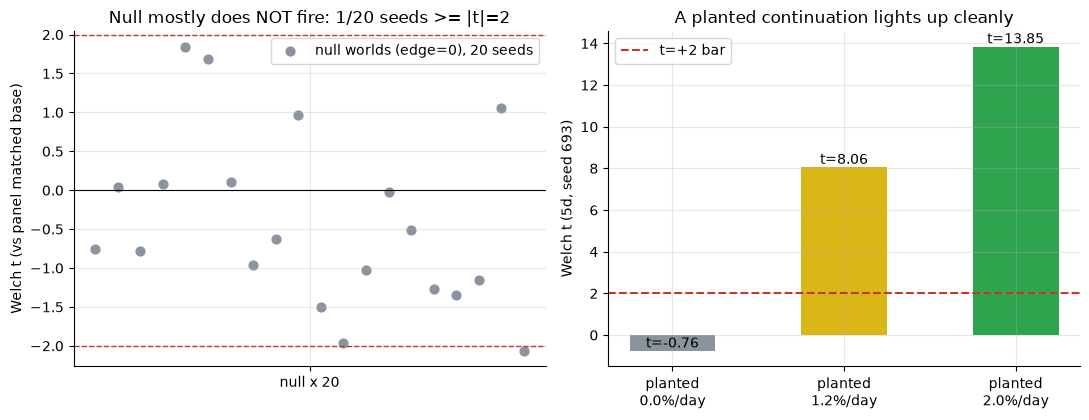

null Welch t: mean=-0.41 sd=1.12 |t|>=2 in 1/20
planted +0.0%/day: n=599 mean=-0.104% t_welch=-0.76 t_hac(vs0)=-0.82 hit=50%
planted +1.2%/day: n=591 mean=+1.119% t_welch=8.06 t_hac(vs0)=8.60 hit=65%
planted +2.0%/day: n=591 mean=+1.929% t_welch=13.85 t_hac(vs0)=14.85 hit=72%


In [8]:
null_welch = []
for s_ in range(20):
    px, _ = data.synthetic_panel(edge=0.0, seed=693 + s_)
    null_welch.append(st.summarize(px, 5, placebo=False)['t_welch'])
null_welch = np.asarray(null_welch)
res = []
for edge in (0.0, 0.012, 0.020):
    px, truth = data.synthetic_panel(edge=edge, seed=693)
    s = st.summarize(px, 5, n_draws=4000, placebo=False)
    res.append((edge, truth['n_planted_days'], s['n_events'], s['mean']*100, s['t_welch'], s['t_hac'], s['hit']*100))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.scatter(np.zeros(20) + np.linspace(-.1,.1,20), null_welch, color=GREY, s=40, label='null worlds (edge=0), 20 seeds')
a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_xticks([0]); a1.set_xticklabels(['null x 20']); a1.set_ylabel('Welch t (vs panel matched base)')
a1.set_title(f'Null mostly does NOT fire: {int((abs(null_welch)>=2).sum())}/20 seeds >= |t|=2'); a1.legend()
labels = [f'planted\n{e*100:.1f}%/day' for e,_,_,_,_,_,_ in res]
tvals = [r[4] for r in res]
a2.bar(labels, tvals, color=[GREY, AMBER, GREEN], width=.5)
a2.axhline(2, ls='--', c=RED, label='t=+2 bar')
for i,t in enumerate(tvals): a2.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
a2.set_ylabel('Welch t (5d, seed 693)'); a2.set_title('A planted continuation lights up cleanly'); a2.legend()
plt.tight_layout(); plt.show()
print(f'null Welch t: mean={null_welch.mean():+.2f} sd={null_welch.std(ddof=1):.2f} |t|>=2 in {(abs(null_welch)>=2).sum()}/20')
for e,pd_,k,ls,tw,th,w in res: print(f'planted {e*100:+.1f}%/day: n={k} mean={ls:+.3f}% t_welch={tw:.2f} t_hac(vs0)={th:.2f} hit={w:.0f}%')

> 💡 In plain words: with **no** planted continuation, the certifying Welch *t* averages **-0.41** (sd 1.12) across 20 seeds and fires in only **1/20** — right at the ~5% nominal false-positive rate of a two-sided two-sigma bar, not a systematic bias. A planted continuation of 1.2%/day reaches Welch *t* = **8.06**, and 2.0%/day reaches **13.85** — the harness *would* catch a real tasuki continuation if one existed. This is exactly why Welch-vs-matched-base is the number that decides the verdict, not HAC-vs-zero.

## 5 · The verdict

- **Signal `NONE`** — the certifying, direction-matched Welch *t* (event sample vs the basket's own direction-matched unconditional return) never certifies a continuation at any horizon (+0.15 / -2.33 / -1.29 / -0.05 for 1/5/10/20 days), and the sole reading past |2| (5-day) points **backwards** — a mild reversal on the downside leg (*t* = -2.58). Hit rates track the base rate. The mix-matched placebo places the 5-day observed mean where **99.5%** of random draws beat it. **0/30** tickers survive a Bonferroni correction individually. Neither a strict full-range gap nor a genuine prior-trend-context filter rescues it — the trend filter makes the dip *worse*. Carries a **survivorship** caveat that cuts *toward* the long leg and *against* the short leg, reported separately so the asymmetry is visible. NONE, not WEAK.
- **Tradability `MIRAGE`** — flat-to-negative **gross** at every horizon (+0.01% to -0.26%); net of a round-trip cost + short borrow it's worse across the whole 5-10 bps sweep (-0.36% to -0.46%). There is no edge to charge costs against.
- **Predicts continuation? `BUSTED`** — the "gap can't close, the trend has fuel left" reading does not survive a fair comparison to what the same basket does on an ordinary day in the same direction. Neither purity filter saves it, and no individual name in the basket carries a Bonferroni-robust version of the story.

## 6 · Going further

- **Why it fails, mechanically.** A gap-plus-pullback is exactly the setup short-horizon reversal research (Jegadeesh 1990; Lehmann 1990) warns about: the market just made an abrupt move and is already being partly faded, which tends to keep fading a little further on the short side rather than resuming — the opposite of the folklore.
- **The survivorship lever cuts both ways here.** Excluding names that never resumed an uptrend (and delisted) biases the long leg *toward* a working signal; excluding names that never stopped falling biases the short leg *against* one. Reporting the legs separately (4c) makes both directions of this bias visible instead of averaging them away.
- **The gap-pattern neighbours.** [74-mind-the-gap](../../74-mind-the-gap/) is the general fill-rate question across all gap sizes and shapes; [417-island-reversal](../../417-island-reversal/) needs two opposite-direction gaps predicting a **reversal**, the opposite claim; [455-three-methods](../../455-three-methods/) is a five-candle continuation pattern with **no gap** at all — none of them run this study's specific two-same-color-gap-then-opposite-pullback, trend-signed detector.

*The reproducible core is offline and deterministic; the detector is the precise real-body tasuki gap with a strict full-range-gap variant and a genuine-prior-trend filter as myth-checks, and a Bonferroni correction across the 30-name basket. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*